# Analyse de trajectoires par clustering (K-Means) avec TCA

In [1]:
# Importation des librairies nécessaires
import pandas as pd
import numpy as np
from trajectoryclusteringanalysis.tca import TCA

In [2]:
# Chargement des données MVAD (exemple)
df = pd.read_csv('../../data/mvad_data.csv') # Ajout d'une colonne identifiant unique
df.insert(0, 'id', df.index)
df.head()

,id,Sep.93,Oct.93,Nov.93,Dec.93,Jan.94,Feb.94,Mar.94,Apr.94,May.94,...,Sep.98,Oct.98,Nov.98,Dec.98,Jan.99,Feb.99,Mar.99,Apr.99,May.99,Jun.99
0,0,EM,EM,EM,EM,TR,TR,EM,EM,EM,...,EM,EM,EM,EM,EM,EM,EM,EM,EM,EM
1,1,FE,FE,FE,FE,FE,FE,FE,FE,FE,...,HE,HE,HE,HE,HE,HE,HE,HE,HE,HE
2,2,TR,TR,TR,TR,TR,TR,TR,TR,TR,...,EM,EM,EM,EM,EM,EM,EM,EM,JL,JL
3,3,TR,TR,TR,TR,TR,TR,TR,TR,TR,...,EM,JL,JL,JL,JL,JL,JL,JL,JL,JL
4,4,FE,FE,FE,FE,FE,FE,FE,FE,FE,...,HE,HE,HE,HE,HE,HE,HE,HE,HE,HE


## Étape 2 – Initialisation de l’objet TCA

In [3]:
tca = TCA(data=df,
              index_col='id',
              alphabet=["EM", "FE", "HE", "JL", "SC", "TR"],
              states=["employment", "FE", "HE", "joblessness","school", "training"],
              mode='unidimensional',)

INFO:root:TCA object initialized successfully
INFO:root:The unidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (712, 71)
state coding:
   alphabet        label  label encoded
0       EM   employment              1
1       FE           FE              2
2       HE           HE              3
3       JL  joblessness              4
4       SC       school              5
5       TR     training              6


## Methode 1 – Clustering avec K-means on frequency


In [22]:
# Methode 1 – Clustering avec K-means on frequency
labels, centers, inertia = tca.kmeans_on_frequency(
    num_clusters=4,
    random_state=42,
    normalize=False,
)

INFO:root:Performing K-Means clustering with 4 clusters...
INFO:root:K-Means clustering completed.


In [ ]:
#Methode 2 – Clustering avec K-means on wide forrma
# labels, centers, inertia = tca.kmeans_on_wide_format(
#     num_clusters=4,
#     random_state=42,
#     normalize=False,
# )

INFO:root:Performing KMeans clustering on wide-format data with 4 clusters.
INFO:root:KMeans on wide format completed.


In [23]:
print("Labels:", np.unique(labels))
print("Centres:", centers)
print("Inertia:", inertia)

Labels: [1 2 3 4]
Centres: [[22.42635659 35.03875969  2.79069767  3.39534884  3.84496124  2.50387597]
 [52.1143695   5.02639296  0.1202346   2.35190616  2.41935484  7.96774194]
 [ 4.73333333  9.86       37.08        0.98666667 17.16666667  0.17333333]
 [13.17391304  4.59782609  0.18478261 28.82608696  1.94565217 21.27173913]]
Inertia: 345098.59219627036


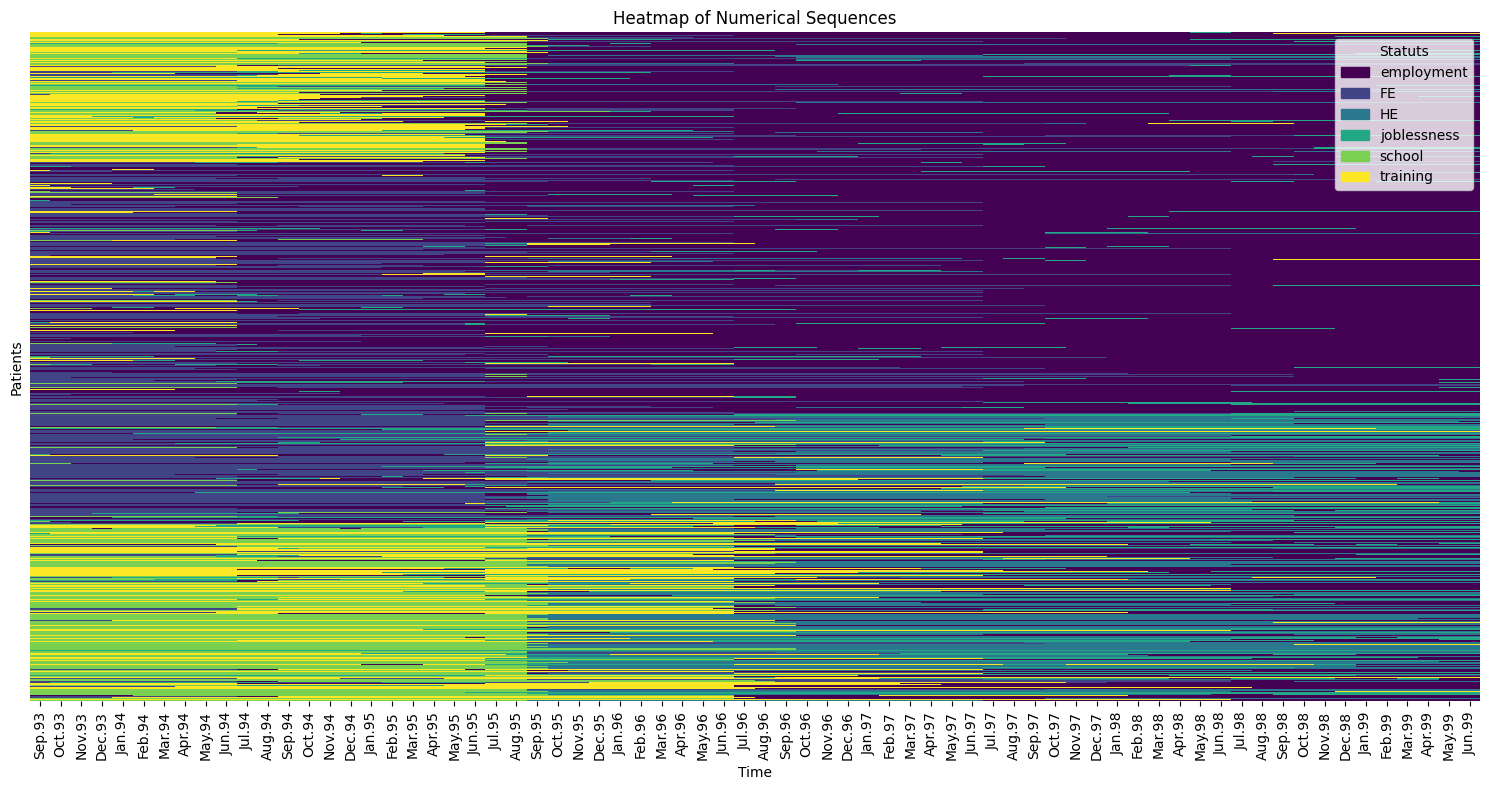

In [20]:
tca.plot_filtered_heatmap(labels=labels, kernel_size=(0, 0))

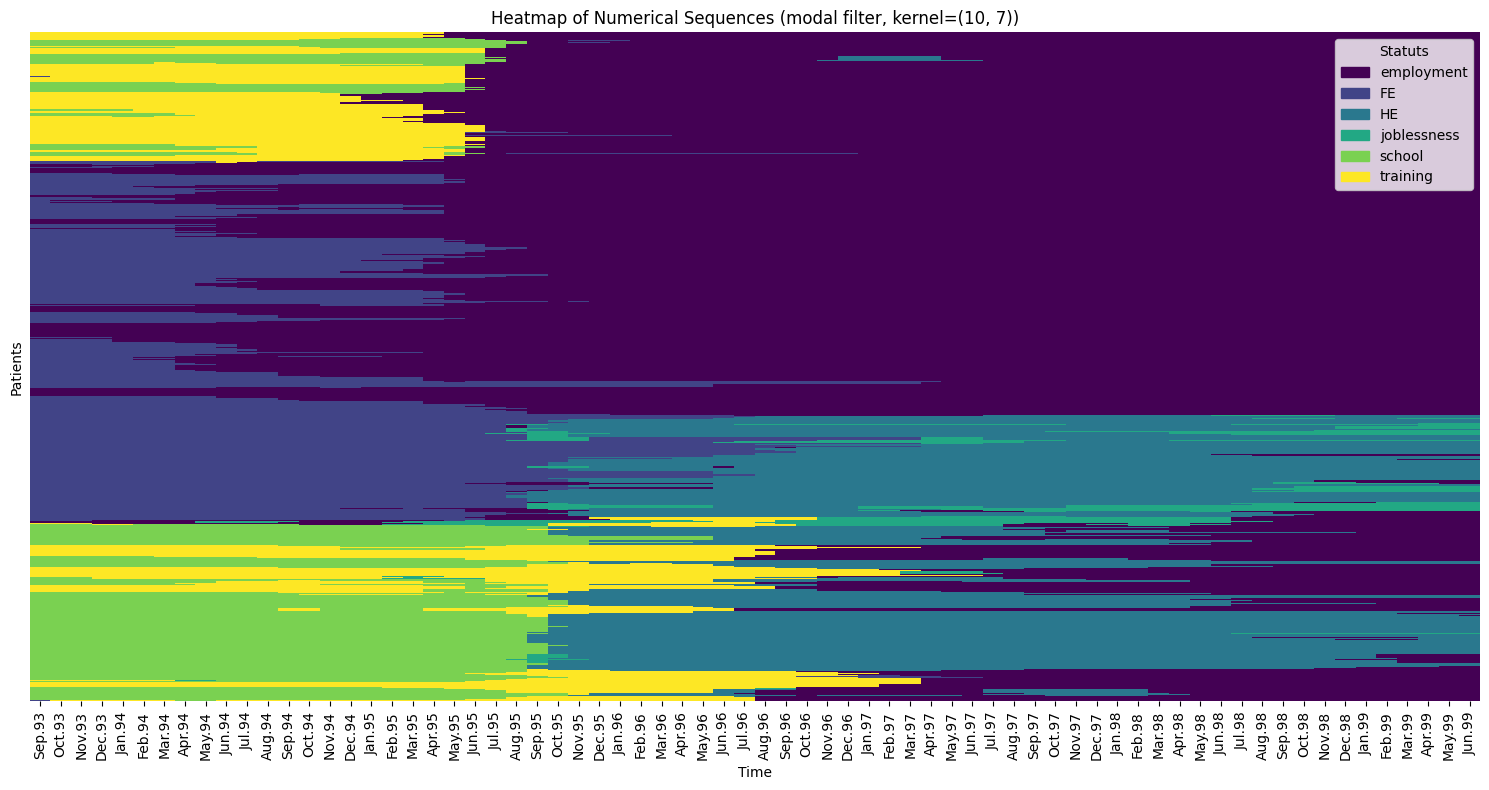

In [21]:
tca.plot_filtered_heatmap(labels=labels, kernel_size=(10, 7))  

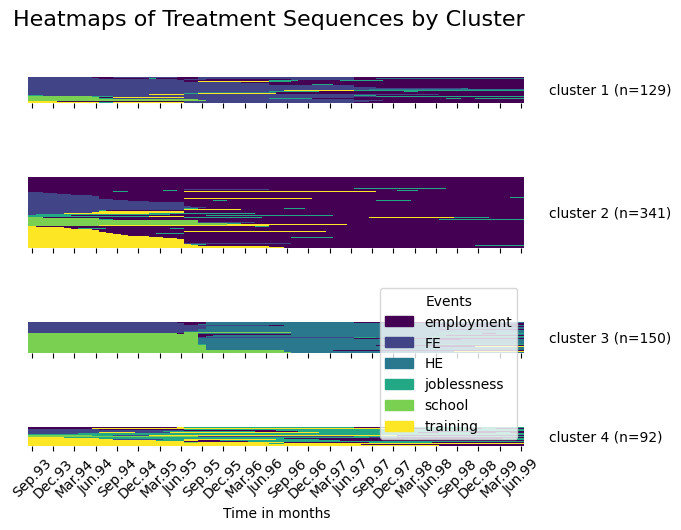

In [10]:
tca.plot_cluster_heatmaps(tca.data,labels, sorted=True)

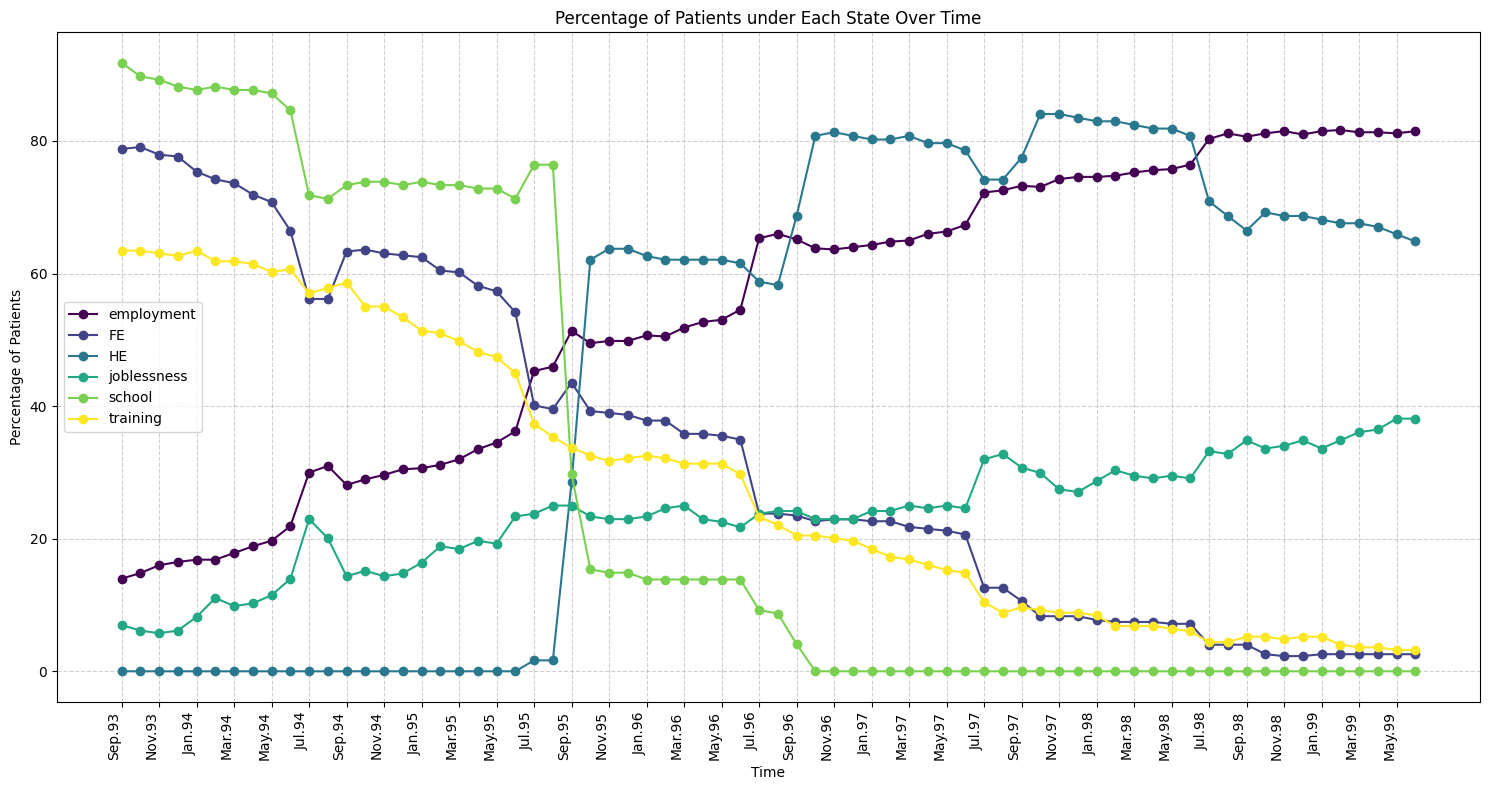

In [11]:
tca.plot_treatment_percentage()

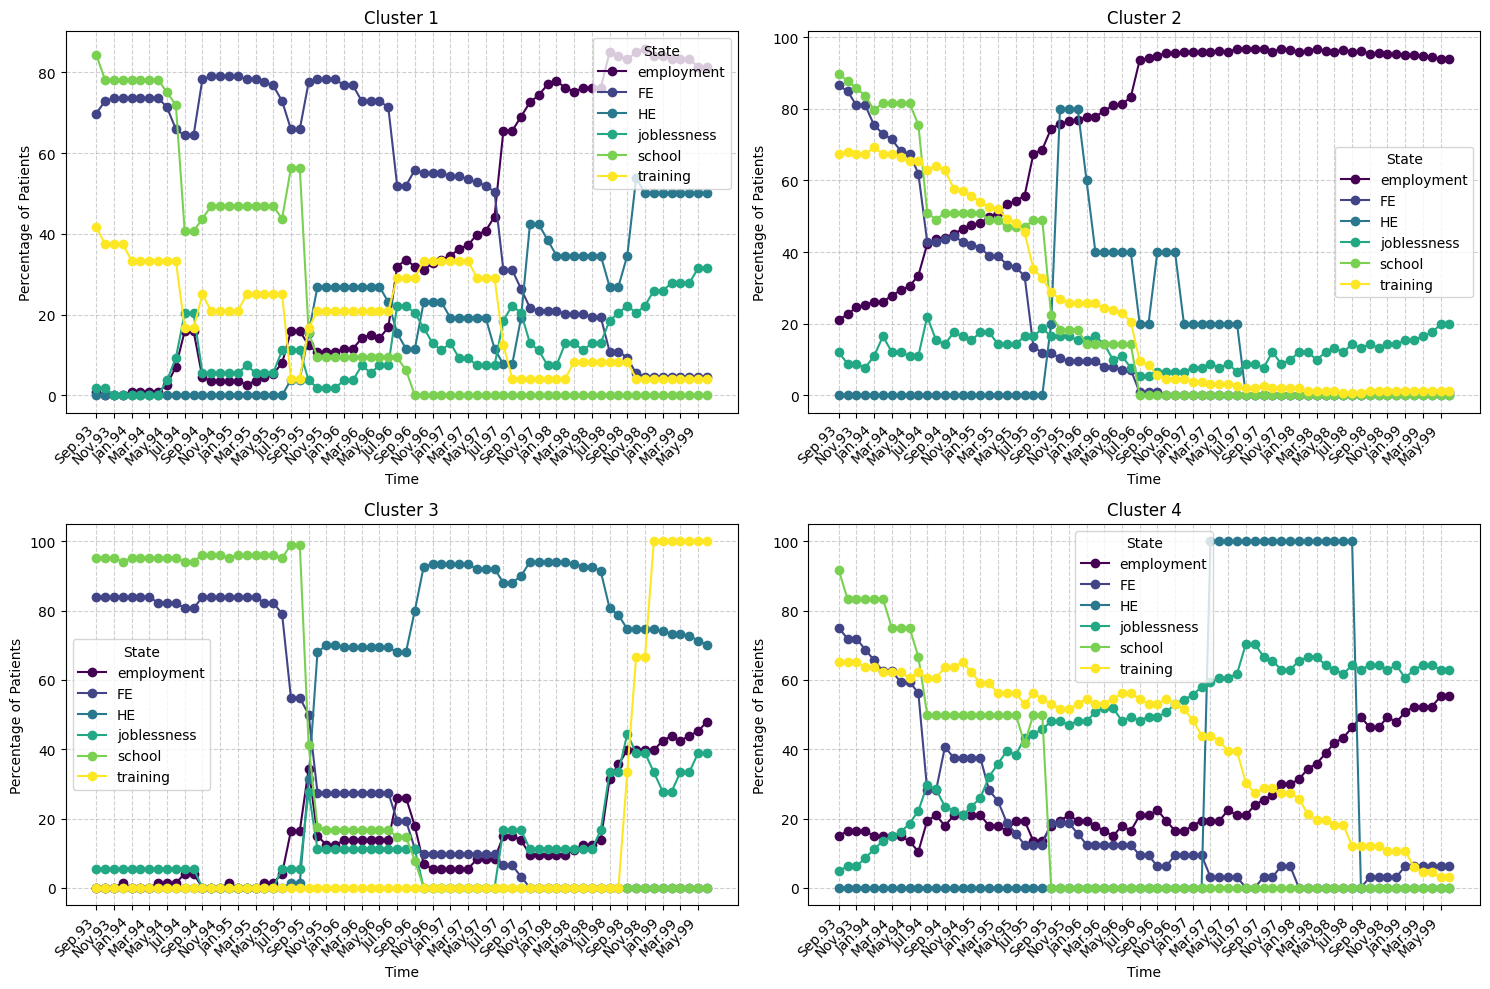

In [12]:
tca.plot_treatment_percentage(labels)

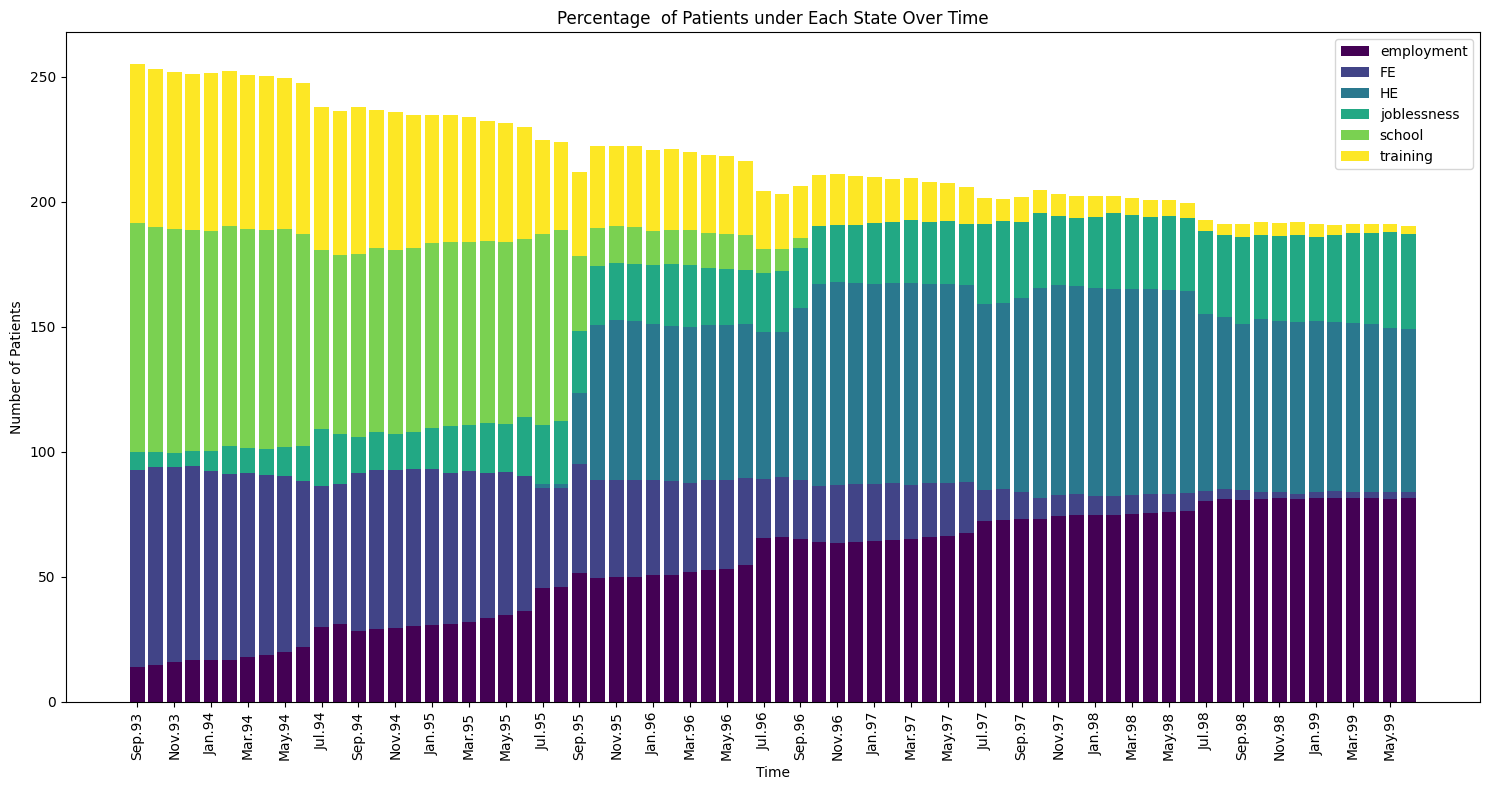

In [13]:
tca.bar_treatment_percentage()

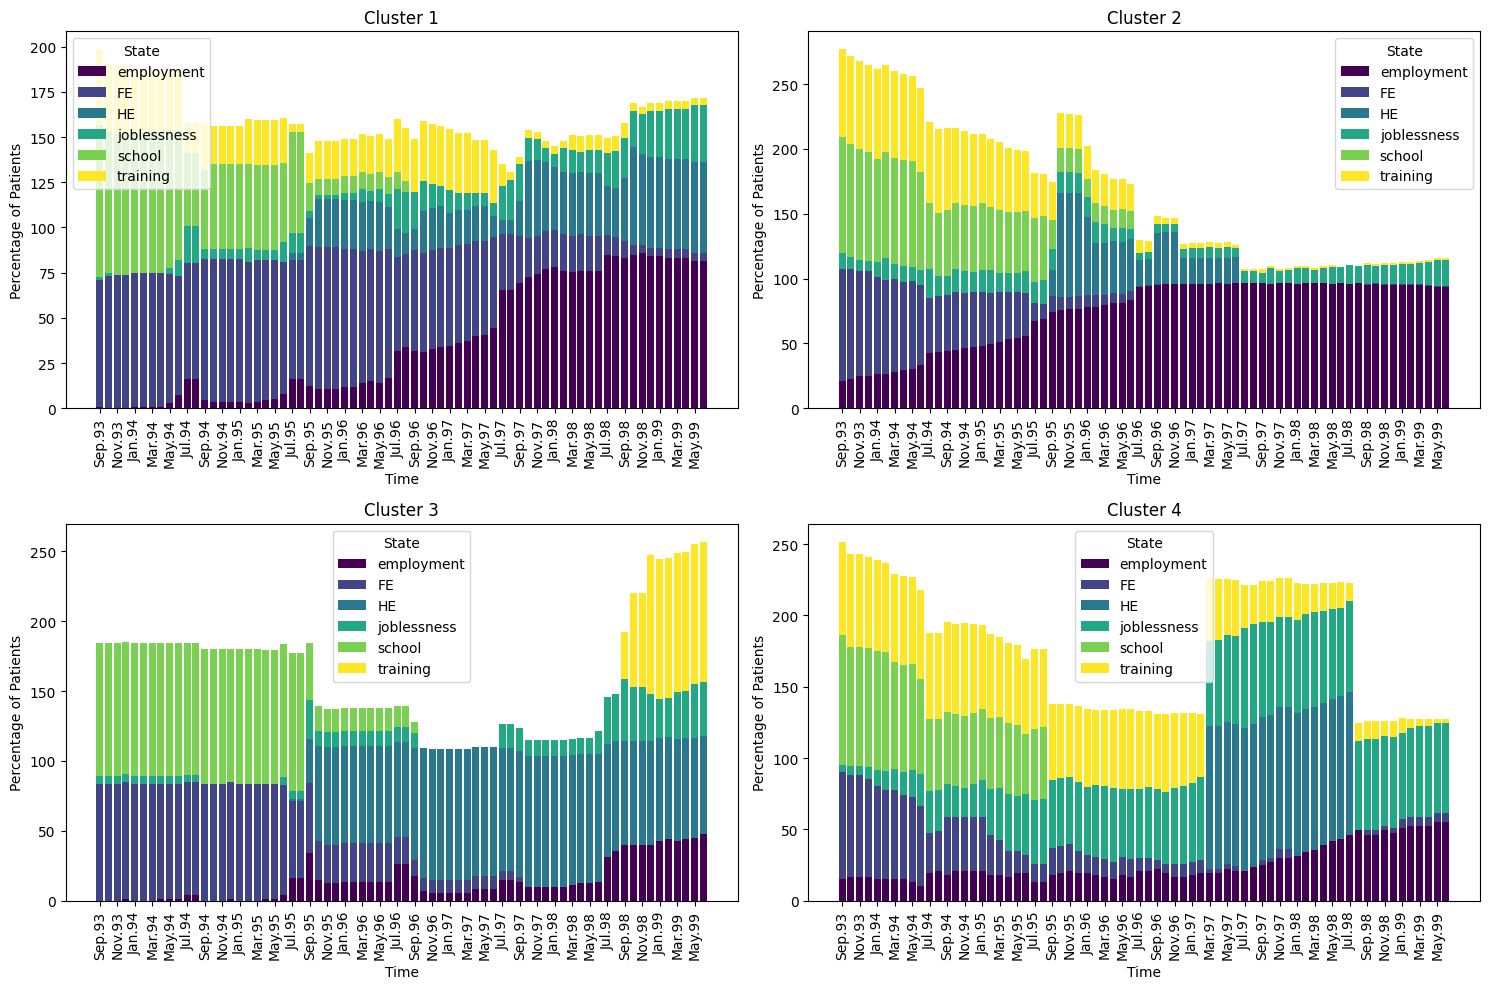

In [14]:
 tca.bar_treatment_percentage(labels)